# 501: Scenario Group Preparation and Supplementary Outputs

Prepares the `all_df_extended` scenario-group dataset (base scenarios, NZGHG-achieving
subset, and both stylised variants) from the compiled 500b component metrics, and
saves the shared `500b_component_metrics_extended_{MANIFEST_ID}.csv` file that
`502`/`503`/`505`/`506`/`507` all read.

This notebook's own outputs, trimmed to just what's still needed:

- **`SFigure_2.png`**: peak-GSAT-vs-NZCO2-timing scatter (supplementary figure).
- **`501_Table_1_synthesis.png`**: the main synthesis table (median share of ensemble
  members, pooled likelihood, post-NZCO2 GSAT change, overshoot degree-years, and the
  ZEC50 sensitivity test), across the four core scenario groups.
- **`501_Table_1_synthesis_supplement.png`**: the same table extended with two more
  groups (`Scenarios (NZCO2 only)` / `Stylised Variants (NZCO2-hold only)` - the
  subset that reaches net-zero CO2 but not net-zero GHG).

The original Table 1a/1b/combined-table analysis (loose decline criterion,
median-of-medians statistics) has been removed - superseded by the synthesis tables'
pooled-probability/percentile methodology.


In [1]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dotenv.load_dotenv()

True

In [2]:
# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)


In [3]:
# Input metrics file - uses combined manifest from 401
MANIFEST_ID = "regenerated"
#METRICS_FILE = OUTPUT_FOLDER / f"500_gsat_metrics_{MANIFEST_ID}.csv"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv"

## Load and Filter Data

In [4]:
# Load 500b component metrics
all_df = pd.read_csv(OUTPUT_FOLDER / METRICS_FILE)

# Filter to rows where net-zero CO2 year extraction was possible
all_df = all_df[all_df["GSAT|ANTHROPOGENIC|netzero_co2"].notna()].copy()
print(f"Rows with valid NZCO2-year extraction: {len(all_df)}")

# Classify scenarios into groups
all_df["scenario_group"] = all_df["scenario"].apply(
    lambda x: "Stylised Variants (NZCO2-hold)" if "NZCO2" in x
    else ("Stylised Variants (NZGHG-hold)" if "NZKyoto" in x else "Scenarios (NZCO2)")
)
# Build set of (model, stripped_scenario) keys from NZKyoto
nzkyoto_combos = set(
    all_df[all_df["scenario_group"] == "Stylised Variants (NZGHG-hold)"]
    .assign(scenario_key=lambda d: d["scenario"].str.replace("_NZKyoto", "", regex=False))
    [["model", "scenario_key"]]
    .itertuples(index=False, name=None)
)

# Find Base rows whose (model, scenario) pair matches a stripped NZKyoto combo
base_df = all_df[all_df["scenario_group"] == "Scenarios (NZCO2)"]
mask = base_df.apply(
    lambda r: (r["model"], r["scenario"]) in nzkyoto_combos, axis=1
)
base_nzghg = base_df[mask].copy()
base_nzghg["scenario_group"] = "Scenarios (NZGHG)"

# Concatenate without overwriting all_df
all_df_extended = pd.concat([all_df, base_nzghg], ignore_index=True)

# Show group counts
group_counts = (
    all_df_extended
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby("scenario_group")
    .agg(
        n_rows=("run_id", "count"),
        n_unique_model_scenarios=("scenario", "count")
    )
)

print("\nScenario group summary:")
group_counts

Rows with valid NZCO2-year extraction: 1173000



Scenario group summary:


,n_rows,n_unique_model_scenarios
scenario_group,,
Scenarios (NZCO2),784,784
Scenarios (NZGHG),387,387
Stylised Variants (NZCO2-hold),784,784
Stylised Variants (NZGHG-hold),387,387


## Classify Ensemble Members

In [5]:
all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|netzero_co2"]
all_df_extended["GSAT|ANTHROPOGENIC|delta_peak_gsat"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|peak"]

In [6]:
# Save here - BEFORE is_decline is added below - so the shared file other notebooks (502, 503, 505, 506, 507) load stays criterion-neutral (just scenario_group and the delta columns). is_decline is this notebook's own classification opinion and should not ride along into a file other notebooks treat as a stable, shared input.
all_df_extended.to_csv(OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv")

In [7]:
rename_map = {
    "Scenarios (NZCO2)":         "Scenarios\n(NZCO2)",
    "Scenarios (NZGHG)":         "Scenarios\n(NZGHG)",
    "Stylised Variants (NZCO2-hold)": "Stylised Variants\n(NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)": "Stylised Variants\n(NZGHG-hold)",
}

In [8]:
groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]


## Supplementary plot on peak vs. NZCO2 timing

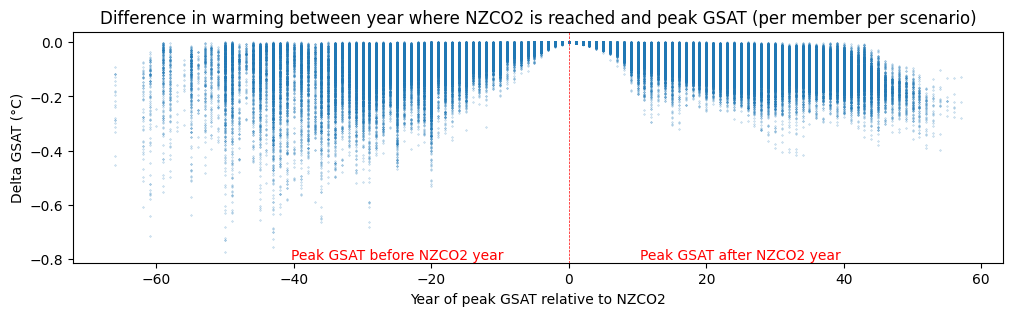

In [9]:
fig, ax = plt.subplots(figsize=(12, 3))

subset = all_df_extended[all_df_extended["scenario_group"]=="Scenarios (NZCO2)"]

x = subset["year_netzero_co2"] - subset["peak_year"]
y = subset["GSAT|ANTHROPOGENIC|netzero_co2"] - subset["GSAT|ANTHROPOGENIC|peak"]

ax.scatter(x, y, marker='x', s=0.8, alpha=.2)
ax.axvline(x=0, linestyle='--', c='red', linewidth=0.5)

# Position text near the top of the plot
y_text = -0.8

ax.text(
    -25,  # halfway between xmin and 0
    y_text,
    "Peak GSAT before NZCO2 year",
    ha="center",
    c="red"
)

ax.text(
    25,     # halfway between 0 and xmax
    y_text,
    "Peak GSAT after NZCO2 year",
    ha="center",
    c="red"
)

ax.set_title("Difference in warming between year where NZCO2 is reached and peak GSAT (per member per scenario)")
ax.set_xlabel("Year of peak GSAT relative to NZCO2")
ax.set_ylabel("Delta GSAT (°C)")

fig.savefig(PLOT_FOLDER / "SFigure_2.png", bbox_inches="tight", dpi=300)
    
plt.show()

# the delta is obviously negative or zero by definition, since otherwise the two years coincide

## Synthesis Table

Combines two different, deliberately-distinguished statistics into one table, using
the **strict** no-further-warming criterion throughout (`peak_year <= year_netzero_co2`
for the peak-timing check, matching 505/502), for both of the two mutually exclusive
strict sub-categories:
- scenarios with no further warming post-NZCO2 (peak at or before NZCO2, 2100 GSAT at
  or below the NZCO2-year level)
- scenarios with post-NZCO2 peak-and-decline GSAT (peak occurs *after* NZCO2, but 2100
  GSAT still ends up below the NZCO2-year level)

1. **Median share of ensemble members in analysed scenarios [%]** - per scenario, the
   share of its 600 MAGICC members satisfying each criterion, then the median of that
   share across scenarios (505's methodology). This represents a **typical scenario**
   in the database, in terms of these criteria - a statement about the median
   pathway, not about the population as a whole.

2. **Likelihood across the full scenario ensemble [%]** - the pooled probability for
   each criterion: pool every (scenario, member) pair and compute the fraction
   satisfying it (equal-weight per scenario, automatic since every scenario has 600
   members). Since a probability is, by definition, a mean/frequency, this pooled
   fraction *is* the actual likelihood statement - unlike the median above, which
   characterizes a representative individual scenario rather than the likelihood
   across the whole population.

   No range is reported alongside these numbers. A cluster-bootstrap CI was tested
   and found to be narrow (~1.5-3 percentage points) - but that narrowness only
   reflects how precisely these numbers are pinned down *given this specific
   784-scenario database*, not the real uncertainty in the underlying claim (which
   includes database-representativeness, model-structural, and deep scenario
   uncertainty the bootstrap can't see). Presenting it in the same "(p17 to p83)"
   notation used for genuine outcome ranges below would risk implying a similar kind
   of uncertainty is being conveyed, when it isn't - so only the point estimates are
   shown here.

3. **Post-NZCO2 GSAT change by 2100 [°C]** - the pooled median and percentiles of
   `delta_netzero_co2` directly. Unlike (2), this *is* a continuous outcome variable
   with genuine, substantively meaningful spread across the pooled population (and,
   empirically, real skew - median and mean noticeably diverge in some groups), so a
   likely range alongside the median is legitimate here, the same way IPCC blends
   climate-response and scenario/model diversity into one "likely range" for a
   continuous outcome, and reports it centered on the median (a percentile itself)
   rather than the mean, for consistency with the surrounding percentile ranges.


In [10]:
# Strict classification (same as 505/502): peak GSAT at or before the net-zero year
# AND 2100 GSAT at or below the net-zero-year level = "no further warming"; peak
# occurs after net-zero but 2100 still ends up lower = "peak-and-decline". These two
# are mutually exclusive by construction.
peak_before_nzco2 = all_df_extended["peak_year"] <= all_df_extended["year_netzero_co2"]
declines_by_2100 = all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] < 0

all_df_extended["no_further_warming_after_nzco2"] = peak_before_nzco2 & (
    all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] <= 0
)
all_df_extended["peak_and_decline_after_nzco2"] = (~peak_before_nzco2) & declines_by_2100

category_sum = (
    all_df_extended["no_further_warming_after_nzco2"].astype(int)
    + all_df_extended["peak_and_decline_after_nzco2"].astype(int)
)
assert (category_sum <= 1).all(), "no_further_warming_after_nzco2 and peak_and_decline_after_nzco2 should be mutually exclusive"

# Third criterion: the original/loose decline criterion - 2100 GSAT returns to the
# NZCO2-year level or below, regardless of peak timing. Defined as the union of the
# two mutually exclusive categories above (rather than independently re-deriving it
# from delta_netzero_co2 <= 0), so the pooled (mean) probabilities of the other two
# are guaranteed to add up to this one exactly - a union of disjoint sets always
# equals the sum of their sizes, by construction.
all_df_extended["returns_to_or_below_nzco2"] = (
    all_df_extended["no_further_warming_after_nzco2"] | all_df_extended["peak_and_decline_after_nzco2"]
)

print("Member-level classification (all groups combined):")
all_df_extended[[
    "no_further_warming_after_nzco2", "peak_and_decline_after_nzco2", "returns_to_or_below_nzco2"
]].mean().mul(100).round(1)


Member-level classification (all groups combined):


no_further_warming_after_nzco2    65.7
peak_and_decline_after_nzco2      15.5
returns_to_or_below_nzco2         81.2
dtype: float64

In [11]:
def per_scenario_probability_median(df, group, criterion_col):
    """Median, across scenarios in `group`, of each scenario's own share of members
    satisfying `criterion_col` (505's per-scenario-probability methodology, reduced
    to just the median point value)."""
    per_scenario_share = (
        df[df["scenario_group"] == group]
        .groupby(["model", "scenario"])[criterion_col]
        .mean() * 100
    )
    return per_scenario_share.median()


median_share_results = pd.DataFrame({
    "no further warming": [per_scenario_probability_median(all_df_extended, g, "no_further_warming_after_nzco2") for g in groups],
    "peak-and-decline": [per_scenario_probability_median(all_df_extended, g, "peak_and_decline_after_nzco2") for g in groups],
    "returns to NZCO2 or below": [per_scenario_probability_median(all_df_extended, g, "returns_to_or_below_nzco2") for g in groups],
}, index=groups)
median_share_results


,no further warming,peak-and-decline,returns to NZCO2 or below
Scenarios (NZCO2),70.166667,13.083333,89.833333
Scenarios (NZGHG),74.000000,20.500000,95.500000
Stylised Variants (NZCO2-hold),67.833333,3.083333,74.833333
Stylised Variants (NZGHG-hold),73.333333,17.833333,92.166667


In [12]:
def pooled_probability(df, group, criterion_col):
    """Pooled probability of `criterion_col` across every (scenario, member) pair in
    `group` (equal-weight-per-scenario, since each scenario has the same member
    count) - the actual likelihood statement, since a probability is by definition a
    mean/frequency. No bootstrap CI - see the markdown above for why one isn't
    reported alongside this number."""
    gdf = df[df["scenario_group"] == group]
    per_scenario = gdf.groupby(["model", "scenario"])[criterion_col].agg(["sum", "count"])
    successes = per_scenario["sum"].to_numpy(dtype=np.int64)
    totals = per_scenario["count"].to_numpy(dtype=np.int64)
    return successes.sum() / totals.sum() * 100


pooled_prob_results = pd.DataFrame({
    "no further warming": [pooled_probability(all_df_extended, g, "no_further_warming_after_nzco2") for g in groups],
    "peak-and-decline": [pooled_probability(all_df_extended, g, "peak_and_decline_after_nzco2") for g in groups],
    "returns to NZCO2 or below": [pooled_probability(all_df_extended, g, "returns_to_or_below_nzco2") for g in groups],
}, index=groups)

# The two mutually exclusive categories should sum exactly to the union - confirms
# the pooled (mean-based) probabilities are additive, unlike the median-based shares.
additivity_check = (
    pooled_prob_results["no further warming"] + pooled_prob_results["peak-and-decline"]
    - pooled_prob_results["returns to NZCO2 or below"]
).abs()
assert (additivity_check < 1e-9).all(), "pooled probabilities should add up exactly"

pooled_prob_results


,no further warming,peak-and-decline,returns to NZCO2 or below
Scenarios (NZCO2),65.205570,17.302509,82.508078
Scenarios (NZGHG),69.125323,23.979759,93.105082
Stylised Variants (NZCO2-hold),62.921131,6.656037,69.577168
Stylised Variants (NZGHG-hold),68.993971,20.987941,89.981912


In [13]:
def pooled_delta_stats(df, group, value_col="GSAT|ANTHROPOGENIC|delta_netzero_co2"):
    """Pooled distribution of delta_netzero_co2 across every (scenario, member) pair
    in `group` - median and percentiles taken directly off the pooled distribution
    (no bootstrap - continuous outcome variable, not a summary parameter). Identical
    methodology to 501b/502b."""
    values = df.loc[df["scenario_group"] == group, value_col]
    n_scenarios = df.loc[df["scenario_group"] == group, ["model", "scenario"]].drop_duplicates().shape[0]
    return {
        "scenario_group": group,
        "n_scenarios": n_scenarios,
        "median": values.median(),
        "p05": values.quantile(0.05),
        "p17": values.quantile(0.17),
        "p83": values.quantile(0.83),
        "p95": values.quantile(0.95),
    }


pooled_delta_results = pd.DataFrame(
    [pooled_delta_stats(all_df_extended, g) for g in groups]
).set_index("scenario_group")
pooled_delta_results


,n_scenarios,median,p05,p17,p83,p95
scenario_group,,,,,,
Scenarios (NZCO2),784,-0.095720,-0.369717,-0.250534,0.001605,0.075764
Scenarios (NZGHG),387,-0.183834,-0.428938,-0.317634,-0.067742,0.023662
Stylised Variants (NZCO2-hold),784,-0.037198,-0.195566,-0.125662,0.042810,0.145831
Stylised Variants (NZGHG-hold),387,-0.144439,-0.322232,-0.245163,-0.041487,0.057248


In [14]:
# Merge in overshoot degree-years (500c_calculate_ody.py's output) - one row per
# (model, scenario, run_id), computed on the cluster from the full annual GSAT
# timeseries. Left-merge on (model, scenario, run_id); "Scenarios (NZGHG)" rows
# (a relabeled duplicate subset of the base scenarios) pick up the same ODY values
# as their "Scenarios (NZCO2)" counterparts automatically, since they share the same
# (model, scenario, run_id) keys.
ody_df = pd.read_csv(OUTPUT_FOLDER / f"500c_ody_{MANIFEST_ID}.csv")
all_df_extended = all_df_extended.merge(
    ody_df[["model", "scenario", "run_id", "ODY"]],
    on=["model", "scenario", "run_id"],
    how="left",
)
print(f"ODY merged - missing values: {all_df_extended['ODY'].isna().sum()} / {len(all_df_extended)}")


def pooled_ody_stats(df, group, value_col="ODY"):
    """Pooled distribution of overshoot degree-years across every (scenario, member)
    pair in `group` - median and percentiles taken directly off the pooled
    distribution, same reasoning as pooled_delta_stats above (continuous outcome
    variable, not a summary parameter - no bootstrap needed)."""
    values = df.loc[df["scenario_group"] == group, value_col]
    n_scenarios = df.loc[df["scenario_group"] == group, ["model", "scenario"]].drop_duplicates().shape[0]
    return {
        "scenario_group": group,
        "n_scenarios": n_scenarios,
        "median": values.median(),
        "p05": values.quantile(0.05),
        "p17": values.quantile(0.17),
        "p83": values.quantile(0.83),
        "p95": values.quantile(0.95),
    }


pooled_ody_results = pd.DataFrame(
    [pooled_ody_stats(all_df_extended, g) for g in groups]
).set_index("scenario_group")
pooled_ody_results


ODY merged - missing values: 0 / 1405200


,n_scenarios,median,p05,p17,p83,p95
scenario_group,,,,,,
Scenarios (NZCO2),784,0.0,0.0,0.0,0.185086,1.311025
Scenarios (NZGHG),387,0.0,0.0,0.0,0.065729,1.086771
Stylised Variants (NZCO2-hold),784,0.0,0.0,0.0,0.566069,2.747007
Stylised Variants (NZGHG-hold),387,0.0,0.0,0.0,0.069782,1.360570


In [15]:
# Sensitivity test: substitute ZEC* (CO2_NZCO2's contribution to delta_netzero_co2)
# with IPCC AR6's assessed ZEC50 range (central estimate 0degC, likely range +-0.19degC;
# no distributional shape given, hence a low/central/high triple rather than a Monte
# Carlo draw - IPCC's +-0.19degC is structural/assessed uncertainty about one true
# value, not member-to-member random noise, so treating it as independently samplable
# per MAGICC ensemble member would misrepresent what the assessment describes).
#
# IPCC's +-0.19degC is for ZEC*50* - a standardized 50-year window - but this study's
# ZEC* is measured over each scenario's own NZCO2-to-2100 window (~10-66 years
# depending on when net-zero is reached). Rescaled here to each member's own actual
# window before substituting (503's ZEC50 rescaling, inverted):
#
#   assumed_delta = assessed_value * (2100 - year_netzero_co2) / 50
#   counterfactual_2100 = actual_2100 - actual_ZEC*_delta + assumed_delta
#
# The "central" (0degC) case reduces exactly to a simple ZEC*-nulled counterfactual.
# Still only the delta <= 0 criterion (not the peak-timing sub-split - recomputing
# whether the peak occurs before/after NZCO2 under a ZEC*-nulled trajectory would need
# the full annual CO2_NZCO2 timeseries per member, not just its scalar delta).
ZEC50_ASSESSED_VALUES = {"low": -0.19, "central": 0.0, "high": 0.19}

window_years = 2100 - all_df_extended["year_netzero_co2"]

median_share_rows_zec = {}
pooled_prob_rows_zec = {}
for label, assessed_value in ZEC50_ASSESSED_VALUES.items():
    assumed_delta = assessed_value * window_years / 50
    counterfactual_2100 = (
        all_df_extended["GSAT|ANTHROPOGENIC|2100"]
        - all_df_extended["GSAT|CO2_NZCO2|delta_netzero_co2"]
        + assumed_delta
    )
    counterfactual_delta = counterfactual_2100 - all_df_extended["GSAT|ANTHROPOGENIC|netzero_co2"]

    col = f"returns_to_or_below_nzco2_zec_{label}"
    all_df_extended[col] = counterfactual_delta <= 0

    median_share_rows_zec[label] = [per_scenario_probability_median(all_df_extended, g, col) for g in groups]
    pooled_prob_rows_zec[label] = [pooled_probability(all_df_extended, g, col) for g in groups]

median_share_results_zec = pd.DataFrame(median_share_rows_zec, index=groups)
pooled_prob_results_zec = pd.DataFrame(pooled_prob_rows_zec, index=groups)

pooled_prob_results_zec


,low,central,high
Scenarios (NZCO2),98.448342,82.475553,36.234694
Scenarios (NZGHG),99.646856,96.521102,66.473299
Stylised Variants (NZCO2-hold),96.333333,65.276786,3.440476
Stylised Variants (NZGHG-hold),99.451335,94.341947,44.008613


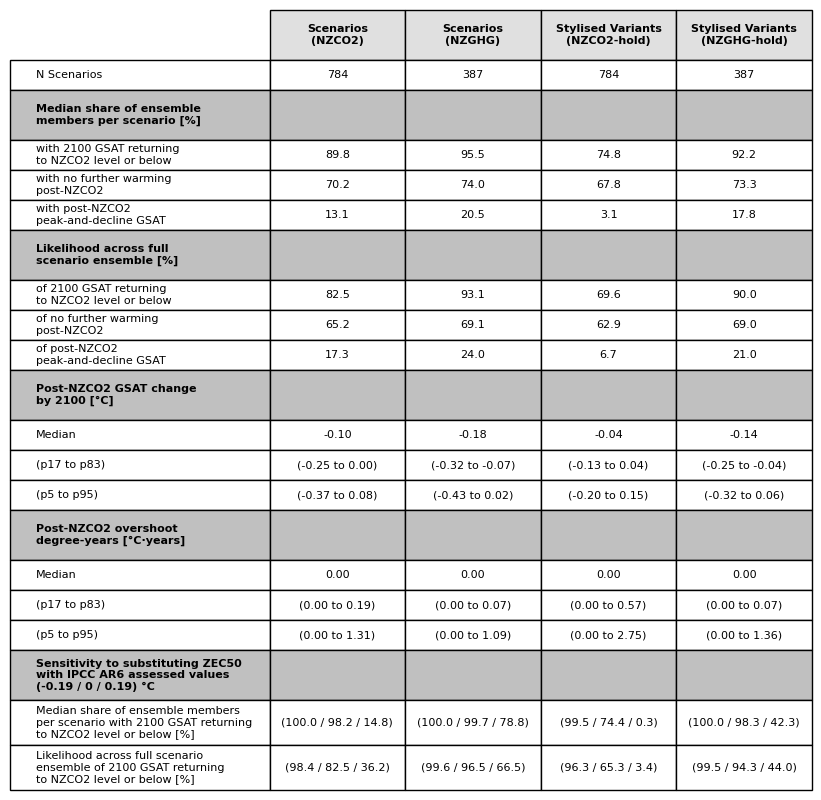

In [16]:
def fmt_pct(x):
    return f"{x:.1f}"


def fmt_degc(x):
    return f"{x:.2f}"


def fmt_ody(x):
    return f"{x:.2f}"


def fmt_triple(low, central, high):
    return f"({fmt_pct(low)} / {fmt_pct(central)} / {fmt_pct(high)})"


n_scenarios_row = ("N Scenarios", [str(int(pooled_delta_results.loc[g, "n_scenarios"])) for g in groups])

section1_rows = [
    ("with 2100 GSAT returning\nto NZCO2 level or below", [fmt_pct(median_share_results.loc[g, "returns to NZCO2 or below"]) for g in groups]),
    ("with no further warming\npost-NZCO2", [fmt_pct(median_share_results.loc[g, "no further warming"]) for g in groups]),
    ("with post-NZCO2\npeak-and-decline GSAT", [fmt_pct(median_share_results.loc[g, "peak-and-decline"]) for g in groups]),
]

section2_rows = [
    ("of 2100 GSAT returning\nto NZCO2 level or below", [fmt_pct(pooled_prob_results.loc[g, "returns to NZCO2 or below"]) for g in groups]),
    ("of no further warming\npost-NZCO2", [fmt_pct(pooled_prob_results.loc[g, "no further warming"]) for g in groups]),
    ("of post-NZCO2\npeak-and-decline GSAT", [fmt_pct(pooled_prob_results.loc[g, "peak-and-decline"]) for g in groups]),
]

section3_rows = [
    ("Median", [fmt_degc(pooled_delta_results.loc[g, "median"]) for g in groups]),
    ("(p17 to p83)", [f"({fmt_degc(pooled_delta_results.loc[g, 'p17'])} to {fmt_degc(pooled_delta_results.loc[g, 'p83'])})" for g in groups]),
    ("(p5 to p95)", [f"({fmt_degc(pooled_delta_results.loc[g, 'p05'])} to {fmt_degc(pooled_delta_results.loc[g, 'p95'])})" for g in groups]),
]

section4_rows = [
    ("Median", [fmt_ody(pooled_ody_results.loc[g, "median"]) for g in groups]),
    ("(p17 to p83)", [f"({fmt_ody(pooled_ody_results.loc[g, 'p17'])} to {fmt_ody(pooled_ody_results.loc[g, 'p83'])})" for g in groups]),
    ("(p5 to p95)", [f"({fmt_ody(pooled_ody_results.loc[g, 'p05'])} to {fmt_ody(pooled_ody_results.loc[g, 'p95'])})" for g in groups]),
]

section5_rows = [
    (
        "Median share of ensemble members\nper scenario with 2100 GSAT returning\nto NZCO2 level or below [%]",
        [fmt_triple(median_share_results_zec.loc[g, "low"], median_share_results_zec.loc[g, "central"], median_share_results_zec.loc[g, "high"]) for g in groups],
    ),
    (
        "Likelihood across full scenario\nensemble of 2100 GSAT returning \nto NZCO2 level or below [%]",
        [fmt_triple(pooled_prob_results_zec.loc[g, "low"], pooled_prob_results_zec.loc[g, "central"], pooled_prob_results_zec.loc[g, "high"]) for g in groups],
    ),
]

section1_label = "Median share of ensemble\nmembers per scenario [%]"
section2_label = "Likelihood across full\nscenario ensemble [%]"
section3_label = "Post-NZCO2 GSAT change\nby 2100 [°C]"
section4_label = "Post-NZCO2 overshoot\ndegree-years [°C·years]"
section5_label = "Sensitivity to substituting ZEC50\nwith IPCC AR6 assessed values\n(-0.19 / 0 / 0.19) °C"

col_labels = [rename_map[g] for g in groups]
n_cols = len(col_labels)

sections = [
    (section1_label, section1_rows),
    (section2_label, section2_rows),
    (section3_label, section3_rows),
    (section4_label, section4_rows),
    (section5_label, section5_rows),
]

row_labels = [n_scenarios_row[0]]
cell_rows = [n_scenarios_row[1]]
section_row_indices = []
section_data_row_indices = {}  # section label -> list of table row indices for its data rows

current_table_row = 2  # table row 0 = column headers, row 1 = N Scenarios data row
for label, rows in sections:
    section_row_indices.append(current_table_row)
    row_labels.append(label)
    cell_rows.append([""] * n_cols)
    current_table_row += 1
    section_data_row_indices[label] = []
    for r_label, r_vals in rows:
        row_labels.append(r_label)
        cell_rows.append(r_vals)
        section_data_row_indices[label].append(current_table_row)
        current_table_row += 1

n_rows = len(row_labels)

fig, ax = plt.subplots(figsize=(7, n_rows * 0.3 + 0.5))
ax.axis("off")

table = ax.table(
    cellText=cell_rows,
    colLabels=col_labels,
    rowLabels=row_labels,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.8)

header_height = 0.1
for col_idx in range(n_cols):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

for row_idx in section_row_indices:
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_height(header_height)
        table[row_idx, col_idx].set_facecolor("#c0c0c0")
        table[row_idx, col_idx].get_text().set_fontweight("bold")
    table[row_idx, -1].set_height(header_height)
    table[row_idx, -1].get_text().set_fontweight("bold")
    table[row_idx, -1].set_facecolor("#c0c0c0")
    table[row_idx, -1].get_text().set_ha("left")

# Section 5's data rows need three lines of row-label text (the other rows only need
# one or two) - give just those two rows extra height rather than the whole table.
tall_row_height = 0.09
for row_idx in section_data_row_indices[section5_label]:
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_height(tall_row_height)
    table[row_idx, -1].set_height(tall_row_height)

plt.savefig(PLOT_FOLDER / "501_Table_1_synthesis.png", dpi=300, bbox_inches="tight")
plt.show()


## Extended Synthesis Table (Supplement)

Same table as above, extended with two additional groups for the supplement - the
subset of scenarios that reach net-zero CO2 but do *not* also reach net-zero Kyoto
GHG, isolating that population from the "Scenarios (NZGHG)"/"Stylised Variants
(NZGHG-hold)" scenarios already mixed in among the original four groups:

- **Scenarios (NZCO2 only)**: `Scenarios (NZCO2)` scenarios whose (model, scenario)
  does *not* also appear in `Scenarios (NZGHG)`.
- **Stylised Variants (NZCO2-hold only)**: the corresponding subset of `Stylised
  Variants (NZCO2-hold)`, matched on the same underlying base scenario.

Built the same way `Scenarios (NZGHG)` itself was constructed in the "Load and Filter
Data" section above - a relabeled duplicate slice of existing rows, concatenated on
for this supplementary table only. Reuses every stats function already defined above
unchanged (they all just filter by `scenario_group`, so a differently-labeled subset
works without modification) - only `all_df_extended` and the group list are
different here, nothing about the underlying methodology changes.


In [17]:
NZCO2_ONLY_LABEL = "Scenarios (NZCO2 only)"
NZCO2_HOLD_ONLY_LABEL = "Stylised Variants (NZCO2-hold only)"

# (model, scenario) pairs that DO achieve net-zero GHG - "Scenarios (NZGHG)" is
# already exactly this subset, relabeled, from the "Load and Filter Data" section.
nzghg_achieving = set(
    all_df_extended.loc[all_df_extended["scenario_group"] == "Scenarios (NZGHG)", ["model", "scenario"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

# Scenarios (NZCO2 only): base scenarios NOT in the NZGHG-achieving set
nzco2_only = all_df_extended[
    (all_df_extended["scenario_group"] == "Scenarios (NZCO2)")
    & ~all_df_extended.apply(lambda r: (r["model"], r["scenario"]) in nzghg_achieving, axis=1)
].copy()
nzco2_only["scenario_group"] = NZCO2_ONLY_LABEL

# Stylised Variants (NZCO2-hold only): same filter, matched on the base scenario name
# (strip the "_NZCO2" suffix before checking against nzghg_achieving)
nzco2_hold = all_df_extended[all_df_extended["scenario_group"] == "Stylised Variants (NZCO2-hold)"].copy()
nzco2_hold_base = nzco2_hold["scenario"].str.replace("_NZCO2", "", regex=False)
nzco2_hold_only = nzco2_hold[
    ~pd.Series(zip(nzco2_hold["model"], nzco2_hold_base), index=nzco2_hold.index).isin(nzghg_achieving)
].copy()
nzco2_hold_only["scenario_group"] = NZCO2_HOLD_ONLY_LABEL

all_df_extended_supp = pd.concat([all_df_extended, nzco2_only, nzco2_hold_only], ignore_index=True)

extended_groups = groups + [NZCO2_ONLY_LABEL, NZCO2_HOLD_ONLY_LABEL]
extended_rename_map = {
    **rename_map,
    NZCO2_ONLY_LABEL: "Scenarios\n(NZCO2 only)",
    NZCO2_HOLD_ONLY_LABEL: "Stylised Variants\n(NZCO2-hold only)",
}

print("Extended group scenario counts:")
print(
    all_df_extended_supp
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby("scenario_group")
    .size()
    .reindex(extended_groups)
)


Extended group scenario counts:


scenario_group
Scenarios (NZCO2)                      784
Scenarios (NZGHG)                      387
Stylised Variants (NZCO2-hold)         784
Stylised Variants (NZGHG-hold)         387
Scenarios (NZCO2 only)                 397
Stylised Variants (NZCO2-hold only)    397
dtype: int64


In [18]:
# Reuses per_scenario_probability_median, pooled_probability, pooled_delta_stats, and
# pooled_ody_stats exactly as defined earlier in this notebook - only the dataframe
# and group list differ.

median_share_results_ext = pd.DataFrame({
    "no further warming": [per_scenario_probability_median(all_df_extended_supp, g, "no_further_warming_after_nzco2") for g in extended_groups],
    "peak-and-decline": [per_scenario_probability_median(all_df_extended_supp, g, "peak_and_decline_after_nzco2") for g in extended_groups],
    "returns to NZCO2 or below": [per_scenario_probability_median(all_df_extended_supp, g, "returns_to_or_below_nzco2") for g in extended_groups],
}, index=extended_groups)

pooled_prob_results_ext = pd.DataFrame({
    "no further warming": [pooled_probability(all_df_extended_supp, g, "no_further_warming_after_nzco2") for g in extended_groups],
    "peak-and-decline": [pooled_probability(all_df_extended_supp, g, "peak_and_decline_after_nzco2") for g in extended_groups],
    "returns to NZCO2 or below": [pooled_probability(all_df_extended_supp, g, "returns_to_or_below_nzco2") for g in extended_groups],
}, index=extended_groups)

pooled_delta_results_ext = pd.DataFrame(
    [pooled_delta_stats(all_df_extended_supp, g) for g in extended_groups]
).set_index("scenario_group")

pooled_ody_results_ext = pd.DataFrame(
    [pooled_ody_stats(all_df_extended_supp, g) for g in extended_groups]
).set_index("scenario_group")

pooled_delta_results_ext


,n_scenarios,median,p05,p17,p83,p95
scenario_group,,,,,,
Scenarios (NZCO2),784,-0.095720,-0.369717,-0.250534,0.001605,0.075764
Scenarios (NZGHG),387,-0.183834,-0.428938,-0.317634,-0.067742,0.023662
Stylised Variants (NZCO2-hold),784,-0.037198,-0.195566,-0.125662,0.042810,0.145831
Stylised Variants (NZGHG-hold),387,-0.144439,-0.322232,-0.245163,-0.041487,0.057248
Scenarios (NZCO2 only),397,-0.034132,-0.220519,-0.126167,0.026682,0.102741
Stylised Variants (NZCO2-hold only),397,-0.020364,-0.155705,-0.084244,0.044875,0.135506


In [19]:
# Same ZEC50 sensitivity as the main table above, computed for the extended six-group
# set. Reuses ZEC50_ASSESSED_VALUES, per_scenario_probability_median, and
# pooled_probability exactly as defined earlier - only the dataframe and group list
# differ. The classification columns (returns_to_or_below_nzco2_zec_*) were already
# added to all_df_extended above, and all_df_extended_supp is a concat of slices of
# all_df_extended, so it already carries them too.
median_share_rows_zec_ext = {}
pooled_prob_rows_zec_ext = {}
for label in ZEC50_ASSESSED_VALUES:
    col = f"returns_to_or_below_nzco2_zec_{label}"
    median_share_rows_zec_ext[label] = [per_scenario_probability_median(all_df_extended_supp, g, col) for g in extended_groups]
    pooled_prob_rows_zec_ext[label] = [pooled_probability(all_df_extended_supp, g, col) for g in extended_groups]

median_share_results_zec_ext = pd.DataFrame(median_share_rows_zec_ext, index=extended_groups)
pooled_prob_results_zec_ext = pd.DataFrame(pooled_prob_rows_zec_ext, index=extended_groups)

pooled_prob_results_zec_ext


,low,central,high
Scenarios (NZCO2),98.448342,82.475553,36.234694
Scenarios (NZGHG),99.646856,96.521102,66.473299
Stylised Variants (NZCO2-hold),96.333333,65.276786,3.440476
Stylised Variants (NZGHG-hold),99.451335,94.341947,44.008613
Scenarios (NZCO2 only),97.280017,68.783795,6.757767
Stylised Variants (NZCO2-hold only),95.802267,56.877834,1.533165


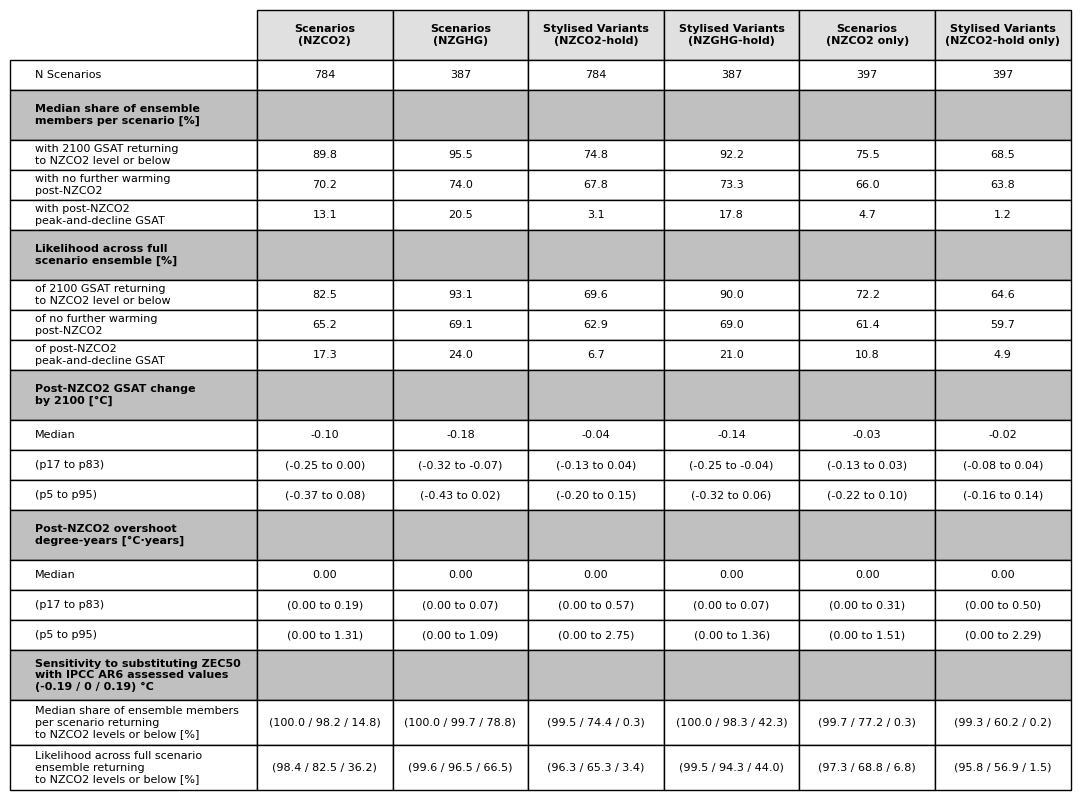

In [20]:
n_scenarios_row_ext = ("N Scenarios", [str(int(pooled_delta_results_ext.loc[g, "n_scenarios"])) for g in extended_groups])

section1_rows_ext = [
    ("with 2100 GSAT returning\nto NZCO2 level or below", [fmt_pct(median_share_results_ext.loc[g, "returns to NZCO2 or below"]) for g in extended_groups]),
    ("with no further warming\npost-NZCO2", [fmt_pct(median_share_results_ext.loc[g, "no further warming"]) for g in extended_groups]),
    ("with post-NZCO2\npeak-and-decline GSAT", [fmt_pct(median_share_results_ext.loc[g, "peak-and-decline"]) for g in extended_groups]),
]

section2_rows_ext = [
    ("of 2100 GSAT returning\nto NZCO2 level or below", [fmt_pct(pooled_prob_results_ext.loc[g, "returns to NZCO2 or below"]) for g in extended_groups]),
    ("of no further warming\npost-NZCO2", [fmt_pct(pooled_prob_results_ext.loc[g, "no further warming"]) for g in extended_groups]),
    ("of post-NZCO2\npeak-and-decline GSAT", [fmt_pct(pooled_prob_results_ext.loc[g, "peak-and-decline"]) for g in extended_groups]),
]

section3_rows_ext = [
    ("Median", [fmt_degc(pooled_delta_results_ext.loc[g, "median"]) for g in extended_groups]),
    ("(p17 to p83)", [f"({fmt_degc(pooled_delta_results_ext.loc[g, 'p17'])} to {fmt_degc(pooled_delta_results_ext.loc[g, 'p83'])})" for g in extended_groups]),
    ("(p5 to p95)", [f"({fmt_degc(pooled_delta_results_ext.loc[g, 'p05'])} to {fmt_degc(pooled_delta_results_ext.loc[g, 'p95'])})" for g in extended_groups]),
]

section4_rows_ext = [
    ("Median", [fmt_ody(pooled_ody_results_ext.loc[g, "median"]) for g in extended_groups]),
    ("(p17 to p83)", [f"({fmt_ody(pooled_ody_results_ext.loc[g, 'p17'])} to {fmt_ody(pooled_ody_results_ext.loc[g, 'p83'])})" for g in extended_groups]),
    ("(p5 to p95)", [f"({fmt_ody(pooled_ody_results_ext.loc[g, 'p05'])} to {fmt_ody(pooled_ody_results_ext.loc[g, 'p95'])})" for g in extended_groups]),
]

section5_rows_ext = [
    (
        "Median share of ensemble members\nper scenario returning\nto NZCO2 levels or below [%]",
        [fmt_triple(median_share_results_zec_ext.loc[g, "low"], median_share_results_zec_ext.loc[g, "central"], median_share_results_zec_ext.loc[g, "high"]) for g in extended_groups],
    ),
    (
        "Likelihood across full scenario\nensemble returning \nto NZCO2 levels or below [%]",
        [fmt_triple(pooled_prob_results_zec_ext.loc[g, "low"], pooled_prob_results_zec_ext.loc[g, "central"], pooled_prob_results_zec_ext.loc[g, "high"]) for g in extended_groups],
    ),
]

col_labels_ext = [extended_rename_map[g] for g in extended_groups]
n_cols_ext = len(col_labels_ext)

sections_ext = [
    (section1_label, section1_rows_ext),
    (section2_label, section2_rows_ext),
    (section3_label, section3_rows_ext),
    (section4_label, section4_rows_ext),
    (section5_label, section5_rows_ext),
]

row_labels_ext = [n_scenarios_row_ext[0]]
cell_rows_ext = [n_scenarios_row_ext[1]]
section_row_indices_ext = []
section_data_row_indices_ext = {}

current_table_row = 2  # table row 0 = column headers, row 1 = N Scenarios data row
for label, rows in sections_ext:
    section_row_indices_ext.append(current_table_row)
    row_labels_ext.append(label)
    cell_rows_ext.append([""] * n_cols_ext)
    current_table_row += 1
    section_data_row_indices_ext[label] = []
    for r_label, r_vals in rows:
        row_labels_ext.append(r_label)
        cell_rows_ext.append(r_vals)
        section_data_row_indices_ext[label].append(current_table_row)
        current_table_row += 1

n_rows_ext = len(row_labels_ext)

fig, ax = plt.subplots(figsize=(10.5, n_rows_ext * 0.3 + 0.5))
ax.axis("off")

table = ax.table(
    cellText=cell_rows_ext,
    colLabels=col_labels_ext,
    rowLabels=row_labels_ext,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.8)

header_height = 0.1
for col_idx in range(n_cols_ext):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

for row_idx in section_row_indices_ext:
    for col_idx in range(n_cols_ext):
        table[row_idx, col_idx].set_height(header_height)
        table[row_idx, col_idx].set_facecolor("#c0c0c0")
        table[row_idx, col_idx].get_text().set_fontweight("bold")
    table[row_idx, -1].set_height(header_height)
    table[row_idx, -1].get_text().set_fontweight("bold")
    table[row_idx, -1].set_facecolor("#c0c0c0")
    table[row_idx, -1].get_text().set_ha("left")

# Section 5's data rows need three lines of row-label text (the other rows only need
# one or two) - give just those two rows extra height rather than the whole table.
tall_row_height = 0.09
for row_idx in section_data_row_indices_ext[section5_label]:
    for col_idx in range(n_cols_ext):
        table[row_idx, col_idx].set_height(tall_row_height)
    table[row_idx, -1].set_height(tall_row_height)

plt.savefig(PLOT_FOLDER / "501_Table_1_synthesis_supplement.png", dpi=300, bbox_inches="tight")
plt.show()
